In [1]:
import ultralytics

ultralytics.checks()# 버전 사용환경

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 192.7/475.9 GB disk)


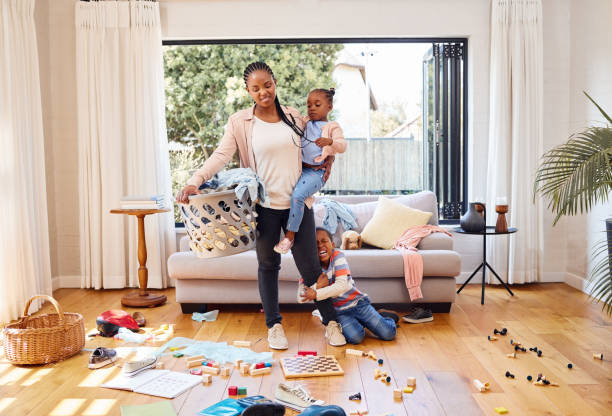

In [20]:
from PIL import Image # Pillow
from IPython.display import display

output_file = "istockphoto-1369539793-612x612.jpg"

with Image.open(output_file) as test_image:
    display(test_image)

In [21]:
from ultralytics import YOLO

# MS COCO 데이터셋 사전학습된 yolov8 모델 로드함
model = YOLO('yolov8n.pt')

In [22]:
print(type(model.names), len(model.names))
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

In [23]:
results = model.predict(source='*.jpg', save=True)

image 1/5 c:\Users\Admin\hipython\objdect\000881.jpg: 640x640 1 kite, 25.5ms
image 2/5 c:\Users\Admin\hipython\objdect\istockphoto-1369539793-612x612.jpg: 448x640 3 persons, 1 couch, 2 potted plants, 20.9ms
image 3/5 c:\Users\Admin\hipython\objdect\rps.jpg: 512x640 3 persons, 21.0ms
image 4/5 c:\Users\Admin\hipython\objdect\street2.jpg: 384x640 13 persons, 12 cars, 18.3ms
image 5/5 c:\Users\Admin\hipython\objdect\ (1).jpg: 640x576 1 bed, 17.0ms
Speed: 3.3ms preprocess, 20.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)
Results saved to C:\Users\Admin\hipython\objdect\runs\detect\predict2


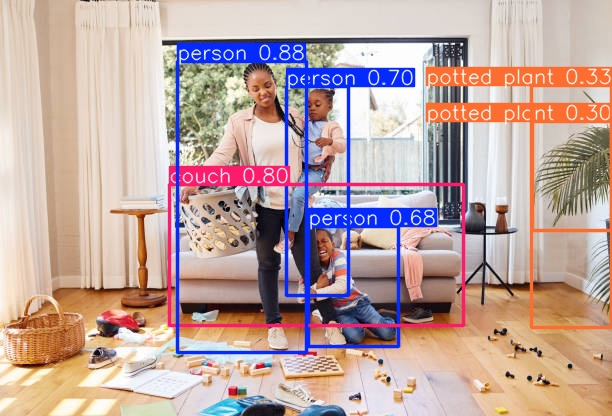

In [25]:
from PIL import Image
from IPython.display import display

with Image.open('runs/detect/predict2/'+output_file) as pred_image:
    # 이미지를 display 함수를 사용하여 표시합니다.
    display(pred_image)

In [8]:
import numpy as np

for result in results:

    uniq, cnt = np.unique(result.boxes.cls.cpu().numpy(), return_counts=True)  # Torch.Tensor -> numpy
    uniq_cnt_dict = dict(zip(uniq, cnt))

    print('\n{class num:counts} =', uniq_cnt_dict,'\n')

    for c in result.boxes.cls:
        print('class num =', int(c), ', class_name =', model.names[int(c)])


{class num:counts} = {np.float32(33.0): np.int64(1)} 

class num = 33 , class_name = kite

{class num:counts} = {np.float32(0.0): np.int64(3)} 

class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 0 , class_name = person

{class num:counts} = {np.float32(0.0): np.int64(13), np.float32(2.0): np.int64(12)} 

class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 2 , class_name = car
class num = 2 , class_name = car
class num = 2 , class_name = car
class num = 2 , class_name = car
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 2 , class_name = car
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 2 , class_name = car
class num = 2 , class_name = car
class num = 0 , class_name = person
class num = 0 , class_name = person
class num = 2 , class_name = car

In [9]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')
print(type(model.names), len(model.names))
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

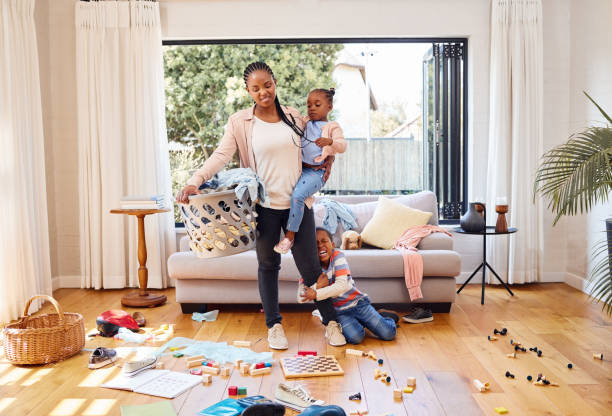

In [28]:
from PIL import Image
from IPython.display import display

# 이미지 파일을 열고
with Image.open('istockphoto-1369539793-612x612.jpg') as test_image1:
    # 이미지를 display 함수를 사용하여 표시합니다.
    display(test_image1)

In [29]:
results = model.predict(source='istockphoto-1369539793-612x612.jpg', save=True)


image 1/1 c:\Users\Admin\hipython\objdect\istockphoto-1369539793-612x612.jpg: 448x640 3 persons, 1 couch, 2 potted plants, 20.2ms
Speed: 3.1ms preprocess, 20.2ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\Admin\hipython\objdect\runs\detect\predict2


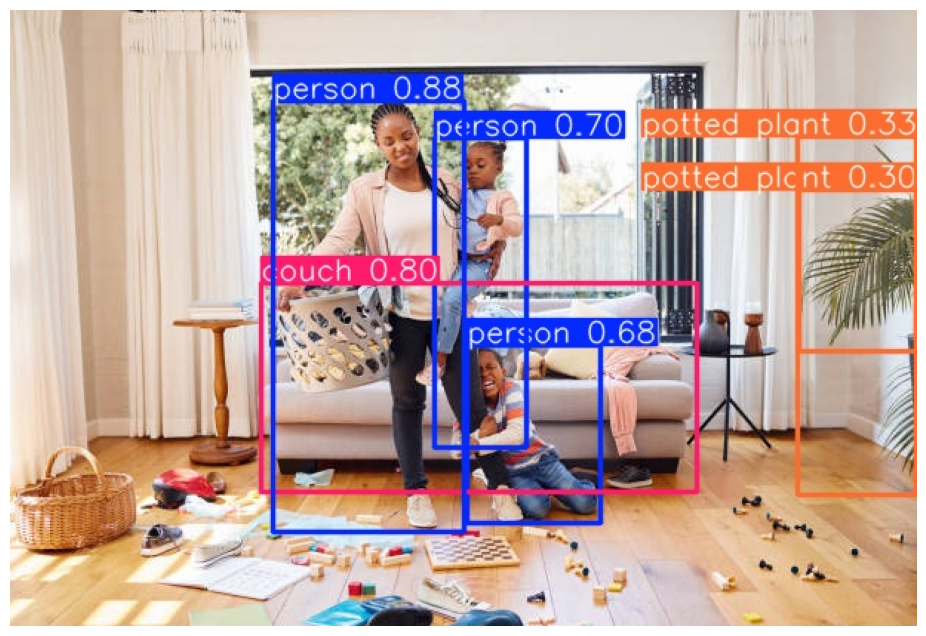

In [31]:
import cv2
import matplotlib.pyplot as plt

result_img = cv2.imread("runs/detect/predict2/istockphoto-1369539793-612x612.jpg")

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
